In [169]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler


In [170]:
df = pd.read_csv('heart_failure_clinical_records_dataset.csv')
display(df.head())
display(df.describe())

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582.0,0,20,1,265000.00,1.9,130,1,0,4,1.0
1,55.0,0,7861.0,0,38,0,263358.03,1.1,136,1,0,6,1.0
2,65.0,0,146.0,0,20,0,162000.00,1.3,129,1,1,7,1.0
3,50.0,1,111.0,0,20,0,210000.00,1.9,137,1,0,7,1.0
4,65.0,1,160.0,1,20,0,327000.00,2.7,116,0,0,8,1.0


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,298.000000,299.000000,298.000000,299.000000,299.000000,299.000000,298.000000,299.00000,299.000000,299.000000,299.00000,299.000000,298.000000
mean,60.803134,0.431438,583.486577,0.418060,38.083612,0.351171,263358.029262,1.39388,136.625418,0.648829,0.32107,130.260870,0.318792
std,11.902900,0.496107,971.501186,0.494067,11.834841,0.478136,97968.752102,1.03451,4.412477,0.478136,0.46767,77.614208,0.466792
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.000000
25%,51.000000,0.000000,118.250000,0.000000,30.000000,0.000000,212250.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.000000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.000000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303750.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.000000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.000000


In [171]:
print("Shape: ", df.shape)
display("rows:", df[0:0])
display(df.dtypes.to_frame('Data Types'))
display(df.isna().sum().to_frame('missing'))

Shape:  (299, 13)


'rows:'

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT


,Data Types
age,float64
anaemia,int64
creatinine_phosphokinase,float64
diabetes,int64
ejection_fraction,int64
high_blood_pressure,int64
platelets,float64
serum_creatinine,float64
serum_sodium,int64
sex,int64


,missing
age,1
anaemia,0
creatinine_phosphokinase,1
diabetes,0
ejection_fraction,0
high_blood_pressure,0
platelets,1
serum_creatinine,0
serum_sodium,0
sex,0


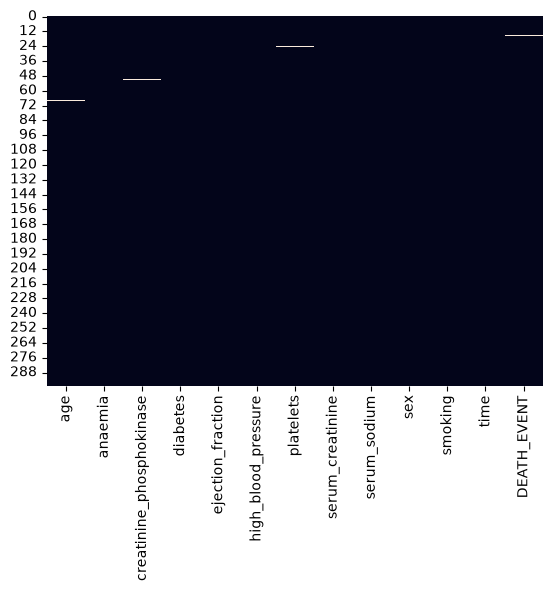

In [172]:
sns.heatmap(df.isnull(), cbar=False)
plt.show()

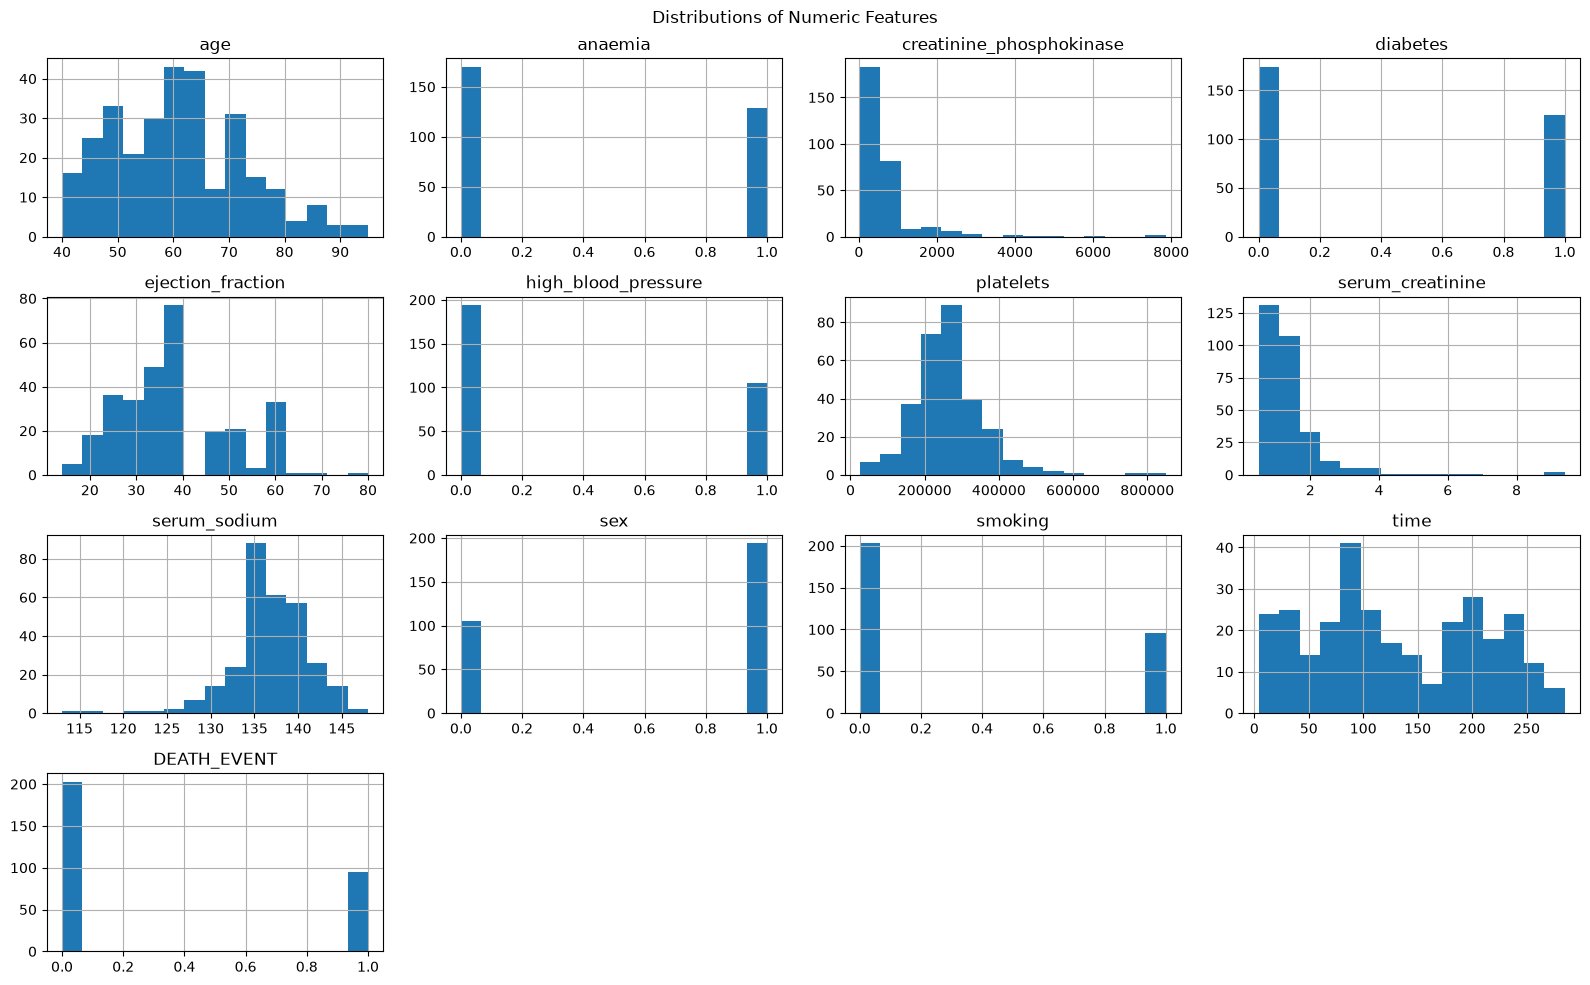

In [173]:
df.hist(figsize=(16, 10), bins=15)
plt.suptitle("Distributions of Numeric Features")
plt.tight_layout()
plt.show()


299

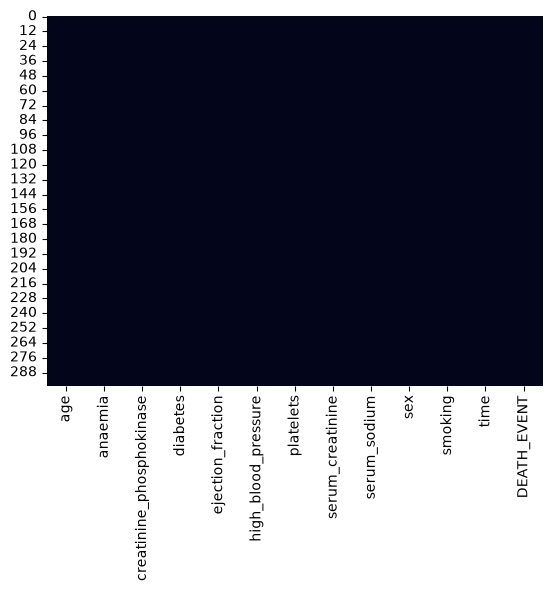

In [174]:
df_clean = df.fillna(df.mean())
sns.heatmap(df_clean.isna(), cbar=False)
len(df_clean)

In [175]:
Q1 = df_clean.quantile(0.25)
Q3 = df_clean.quantile(0.75)
IQR = Q3 - Q1
print(len(df_clean))
df_clean = df_clean[~((df_clean < (Q1 - 1.5 * IQR)) | (df_clean > (Q3 + 1.5 * IQR))).any(axis=1)]
print(len(df_clean))

299
224


In [176]:
print(df[df['age'] < 0])

Empty DataFrame
Columns: [age, anaemia, creatinine_phosphokinase, diabetes, ejection_fraction, high_blood_pressure, platelets, serum_creatinine, serum_sodium, sex, smoking, time, DEATH_EVENT]
Index: []


In [177]:
df_clean['age_group'] = pd.cut(
    df_clean['age'],
    bins=[0, 40, 60, float('inf')],
    labels=[0, 1, 2],
    right=False
)
df_clean['risk_score'] = df_clean['ejection_fraction'] * df_clean['serum_creatinine']
df_clean['risk_score'] = (df_clean['risk_score'] - df_clean['risk_score'].min()) / (df_clean['risk_score'].max() - df_clean['risk_score'].min())
df_clean.head()
print(df_clean.isna().sum())

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
age_group                   0
risk_score                  0
dtype: int64


In [178]:
scaler = MinMaxScaler().set_output(transform="pandas")
df_clean = pd.DataFrame(
    scaler.fit_transform(df_clean), 
    columns=df_clean.columns, 
    index=df_clean.index
)
df_clean.describe()


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT,age_group,risk_score
count,224.000000,224.00000,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000,224.000000
mean,0.377609,0.46875,0.263772,0.419643,0.474090,0.379464,0.438902,0.352381,0.523680,0.642857,0.321429,0.457836,0.272321,0.558036,0.360744
std,0.216912,0.50014,0.238494,0.494606,0.229624,0.486340,0.220176,0.218530,0.165510,0.480231,0.468071,0.272526,0.446151,0.497733,0.187138
min,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.181818,0.00000,0.072526,0.000000,0.313725,0.000000,0.288525,0.200000,0.391304,0.000000,0.000000,0.255338,0.000000,0.000000,0.217845
50%,0.363636,0.00000,0.155717,0.000000,0.470588,0.000000,0.460656,0.333333,0.521739,1.000000,0.000000,0.412811,0.000000,1.000000,0.319235
75%,0.545455,1.00000,0.470990,1.000000,0.607843,1.000000,0.574590,0.466667,0.652174,1.000000,1.000000,0.715302,1.000000,1.000000,0.449594
max,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


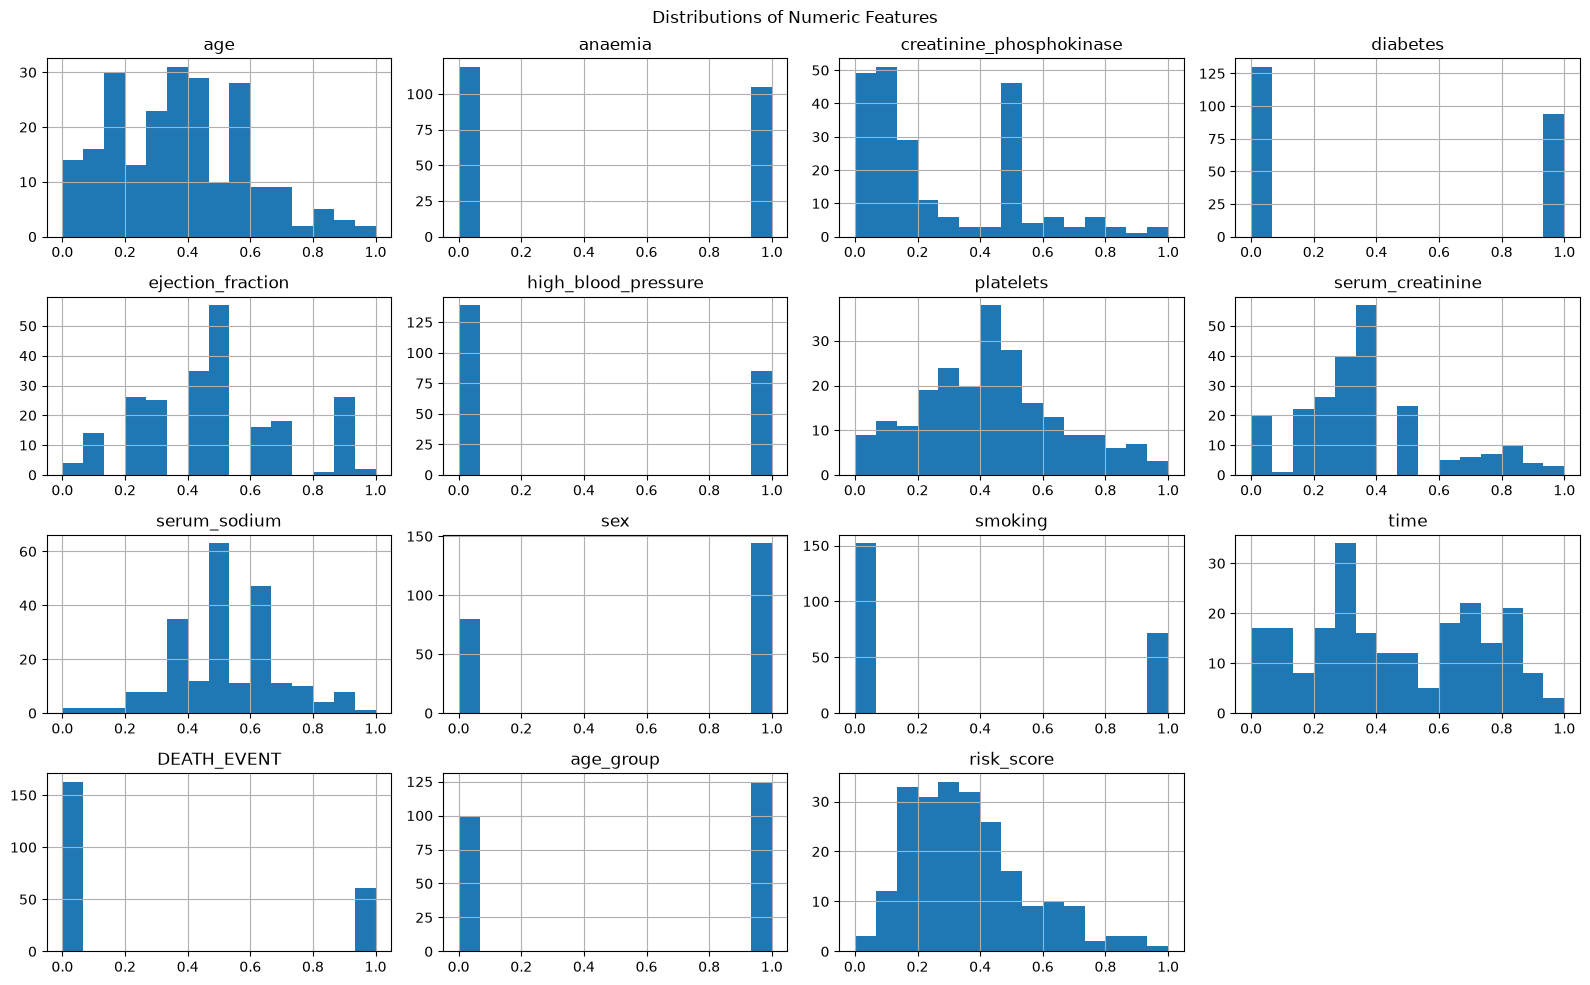

In [179]:
df_clean.hist(figsize=(16, 10), bins=15)
plt.suptitle("Distributions of Numeric Features")
plt.tight_layout()
plt.show()


In [182]:
display(df_clean.isna().sum().to_frame('missing'))
print(df_clean.shape)

,missing
age,0
anaemia,0
creatinine_phosphokinase,0
diabetes,0
ejection_fraction,0
high_blood_pressure,0
platelets,0
serum_creatinine,0
serum_sodium,0
sex,0


(224, 15)
